In [1]:
import sys
import os
print("Python executable:", sys.executable)
print("Python path:", sys.path)
sys.path.append(os.path.abspath("../../../")) 
import numpy as np
import sys
# Import the fitting module

from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
from kingmaker_fork.kingmaker.fitting import KingPSFFitter
import kingmaker_fork.likelihood_analysis.plotting_helpers.fitting_plots as fplt
from  csky_gfu_tests.custom_gfu_specs import coarse_bins_log_energy, coarse_bins_sindec
import csky as cy
timer = cy.timing.Timer()
time = timer.time

Python executable: /home/fkrafft/venvs/icecube-py3v4.4.0/bin/python
Python path: ['/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python312.zip', '/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python3.12', '/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python3.12/lib-dynload', '', '/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages']


Parameters:

In [2]:
signal_event_file: str = '/data/ana/analyses/gfu_online/version-001-p09/IC86_2023_MC.npy'
cache_dir: str = "/data/user/fkrafft/king_fits/likelihood_analysis/IC86_2023_cache.npz" #if already exists -> use cached. else cache it there
weight_field: str = "ow"
angular_cutoff_deg: float = 15 
spectral_indices = [2.5]
dpsi_nbins = 101
minimum_counts = 100

### Load signal events

In [3]:
signal_events = np.load(signal_event_file)
print(str(len(signal_events)) + ' signal events loaded...')

19517177 signal events loaded...


In [5]:
import inspect
from  csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu
ana_dir = cy.utils.ensure_dir('/data/user/fkrafft/csky_gfu_tests')
repo_cache = cy.utils.ensure_dir('/data/user/fkrafft/csky_repo')
repo = cy.selections.Repository(
    local_root = repo_cache,
    remote_root= '/data/ana/PointSource/GFU/online_v001-p10')


print("Repository signature:", inspect.signature(cy.selections.Repository))
print("repo =", repo)
for name in ["root", "local_root", "remote_root", "base_dir", "dir"]:
    print(name, "=", getattr(repo, name, None))


with time('ana setup (from cache-to-disk)'):
    ana = cy.get_analysis(repo, 'version-001-p09' , custom_gfu.gfu_11yr, dir = ana_dir)



Repository signature: (local_root=None, remote_root=None, username=None)
repo = <csky.selections.Repository object at 0x7fa39bc75c40>
root = None
local_root = /data/user/fkrafft/csky_repo
remote_root = /data/ana/PointSource/GFU/online_v001-p10
base_dir = None
dir = None
Setting up Analysis for:
GFU_2011_2022
Setting up GFU_2011_2022...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2023_MC.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2022_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online

('azimuth',
 'dec',
 'sindec',
 'energy',
 'log10energy',
 'event',
 'mjd',
 'ra',
 'run',
 'sigma',
 'subevent',
 'xdec',
 'xra',
 'true_dec',
 'true_energy',
 'true_ra',
 'oneweight')

### Define Bins

We want to use some predefined bins instead of the equal-probability binning, as for full sky analysis we expect physically strong difference in certain regions of events. If we allow our binning method to set the bins based on statistics, it does not account for the physical properties in the region, resulting in poor fitting. 

We start with custom bin edges for now. maybe we can use those bin edges later as a seed grid for finer binning based on equal-probability? 

We will see...

In [4]:
parametrization_bins = {
    'logE':  np.array([2, 3, 4, 5, 6]), #  energy bins from 100 GeV to 1 PeV
    'dec': np.arcsin(np.linspace(-1, 1, 10)),  #  10 equal bins in sin_dec
    'angErr': np.logspace(-4, 0, 9) #try out angular error bins which with log spacing from 10^-4 to 1 rad
    
}

### Initialize Wrapper 

With cache dir we can load existing fitted parameters

In [5]:
king_wrapper = KingSpatialLikelihood(signal_events = signal_events,
                                        parametrization_bins = parametrization_bins,
                                        spectral_indices= spectral_indices,
                                        cache_name = cache_dir,
                                        dpsi_nbins=dpsi_nbins,
                                        minimum_counts=minimum_counts,
                                        weight_field = "ow",
                                        true_ra_name = "trueRa",
                                        true_dec_name = "trueDec",
                                        true_energy_name = "trueE",
                                        angular_cutoff = np.radians(angular_cutoff_deg),
                                       )

Fitting parameter space...
Fitting King PSF in 288 bins...
  Spectral indices: [2.5]
  Binning dimensions: ['logE', 'dec', 'angErr']

  Spectral index γ = 2.50


  9%|▉         | 27/288 [00:00<00:09, 26.70it/s]/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _unnormalized_cdf
  return super().__call__(*args, **kws)
/home/fkrafft/kingmaker_fork/kingmaker/pdf.py:159: RuntimeWarning: invalid value encountered in multiply
  normalized_cdf[mask] = norm * unnormalized_cdf
100%|██████████| 288/288 [01:00<00:00,  4.77it/s]

    Fitted 181 bins, skipped 107 bins

Fitting complete!


### Take a look at fitting...

Choose gamma index of spectral index you want to visualize

In [6]:
gamma_idx = 0

In [7]:
fit_parameters = king_wrapper.fitted_parameters

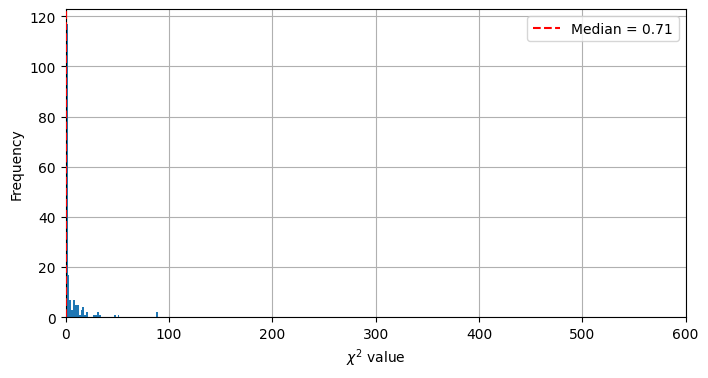

In [8]:
fplt.plot_fit_quality_hist(fit_parameters= fit_parameters, gamma_idx= gamma_idx)

In [10]:
hidden_value = np.deg2rad(0.1)
angerr_bins = fit_parameters["parametrization_bins"]["angErr"]

angerr_idx = np.digitize(hidden_value, angerr_bins) - 1
angerr_idx = np.clip(angerr_idx, 0, len(angerr_bins) - 2)

hidden_slices = {"angErr": angerr_idx}

alpha_vals = fit_parameters["alpha"][gamma_idx]
beta_vals = fit_parameters["beta"][gamma_idx]
event_counts = fit_parameters["event_counts"][gamma_idx]
fit_quality = fit_parameters["fit_quality"][gamma_idx]

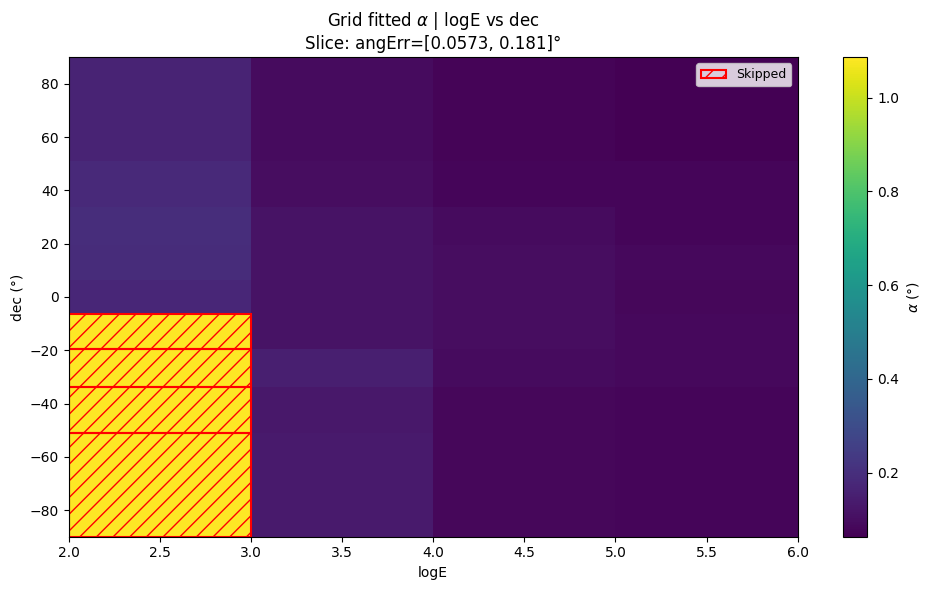

<Axes: title={'center': 'Grid fitted $\\alpha$ | logE vs dec\nSlice: angErr=[0.0573, 0.181]°'}, xlabel='logE', ylabel='dec (°)'>

In [11]:
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | logE vs dec",
    cbar_label="$\\alpha$ (°)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    hidden_slices=hidden_slices,
)

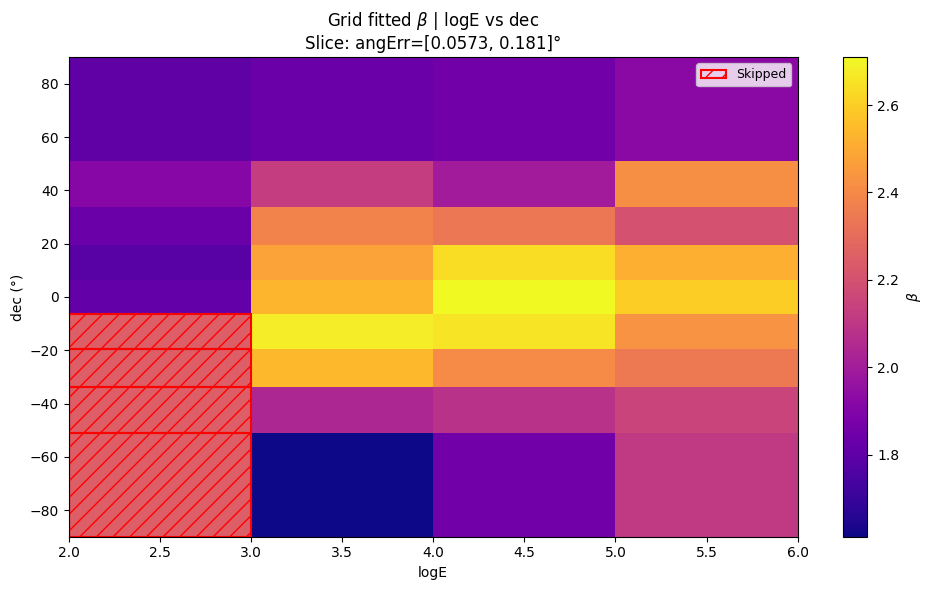

<Axes: title={'center': 'Grid fitted $\\beta$ | logE vs dec\nSlice: angErr=[0.0573, 0.181]°'}, xlabel='logE', ylabel='dec (°)'>

In [12]:
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=beta_vals,
    title="Grid fitted $\\beta$ | logE vs dec",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)

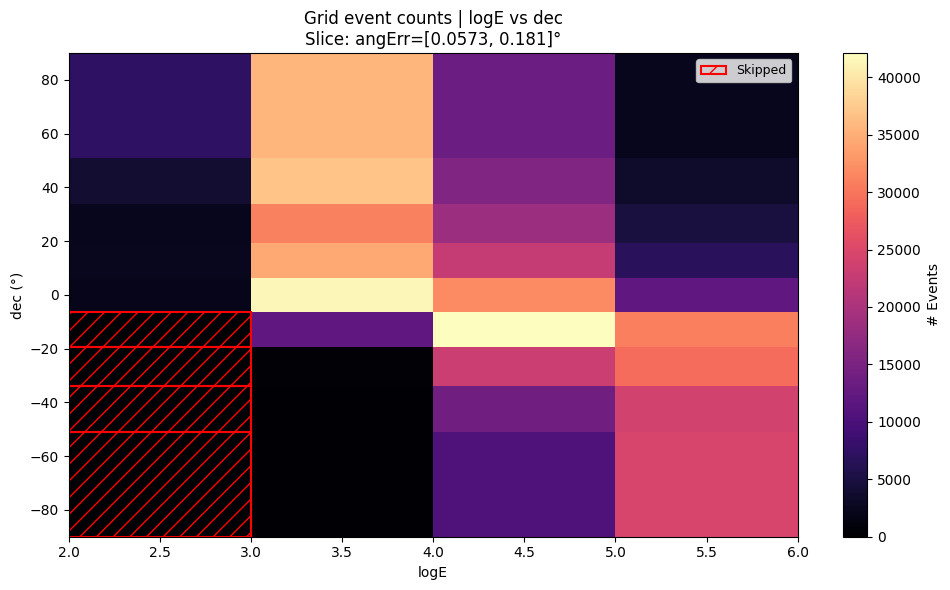

<Axes: title={'center': 'Grid event counts | logE vs dec\nSlice: angErr=[0.0573, 0.181]°'}, xlabel='logE', ylabel='dec (°)'>

In [13]:
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=event_counts,
    title="Grid event counts | logE vs dec",
    cbar_label="# Events",
    cmap="magma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)

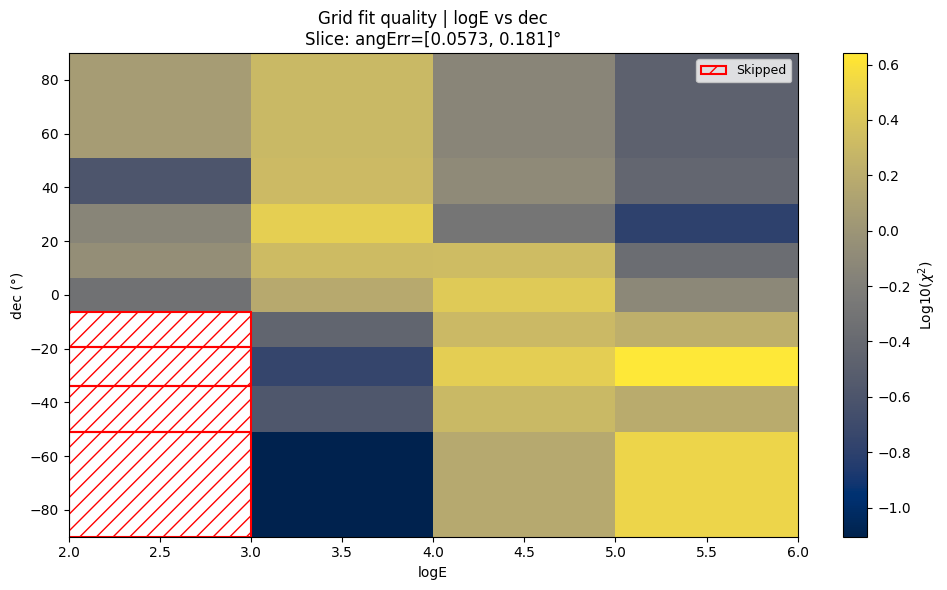

<Axes: title={'center': 'Grid fit quality | logE vs dec\nSlice: angErr=[0.0573, 0.181]°'}, xlabel='logE', ylabel='dec (°)'>

In [14]:
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=fit_quality,
    title="Grid fit quality | logE vs dec",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)

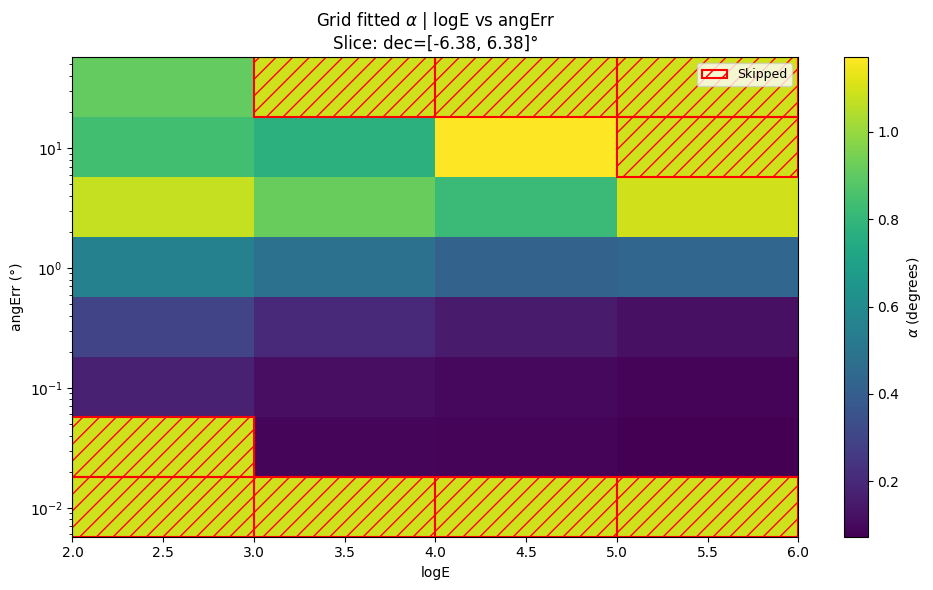

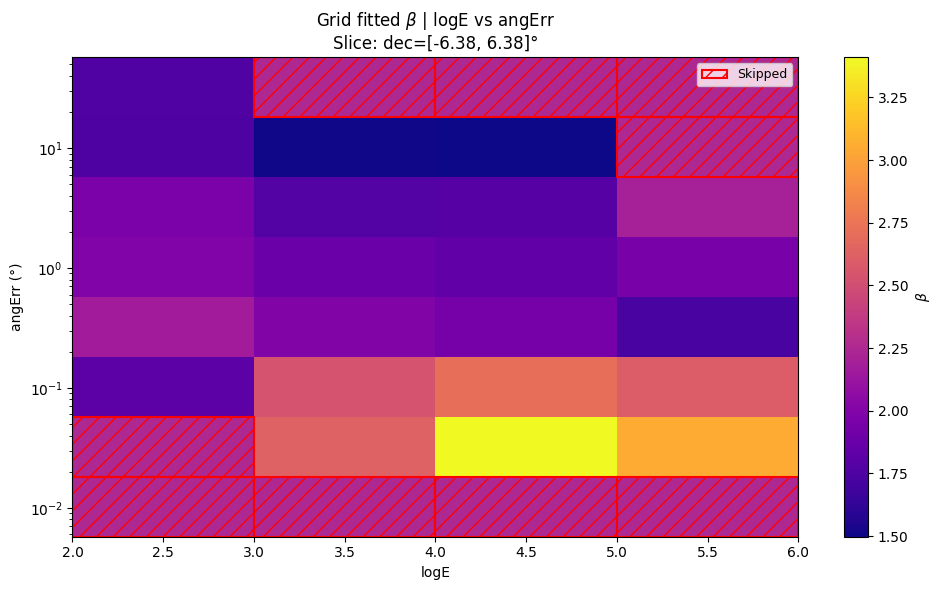

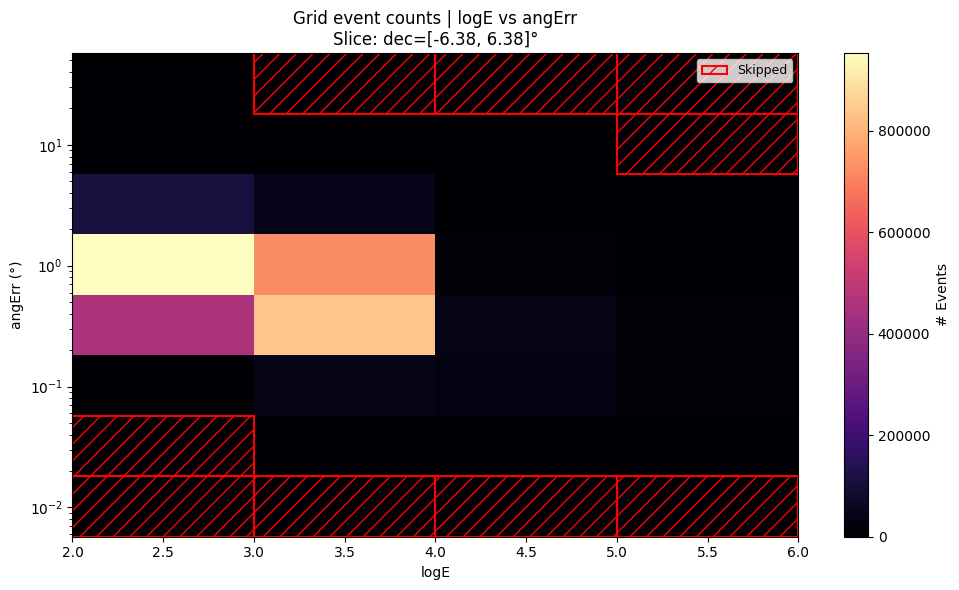

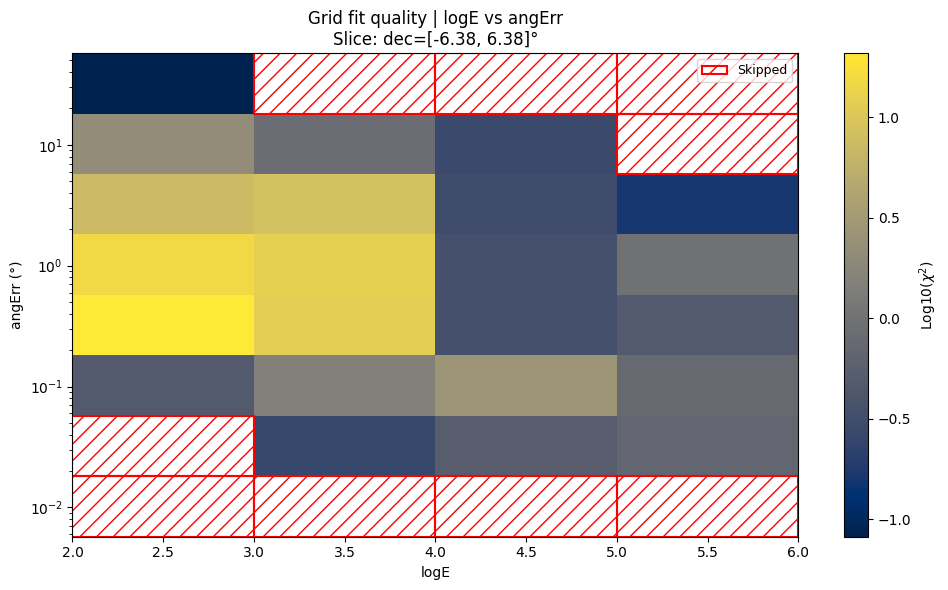

<Axes: title={'center': 'Grid fit quality | logE vs angErr\nSlice: dec=[-6.38, 6.38]°'}, xlabel='logE', ylabel='angErr (°)'>

In [15]:
dec_bins = parametrization_bins["dec"]
dec_idx = len(dec_bins) // 2 - 1

hidden_slices = {"dec": dec_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | logE vs angErr",
    cbar_label="$\\alpha$ (degrees)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=beta_vals,
    title="Grid fitted $\\beta$ | logE vs angErr",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=event_counts,
    title="Grid event counts | logE vs angErr",
    cbar_label="# Events",
    cmap="magma",
    y_to_degrees=True,
    log_values=False,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=fit_quality,
    title="Grid fit quality | logE vs angErr",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

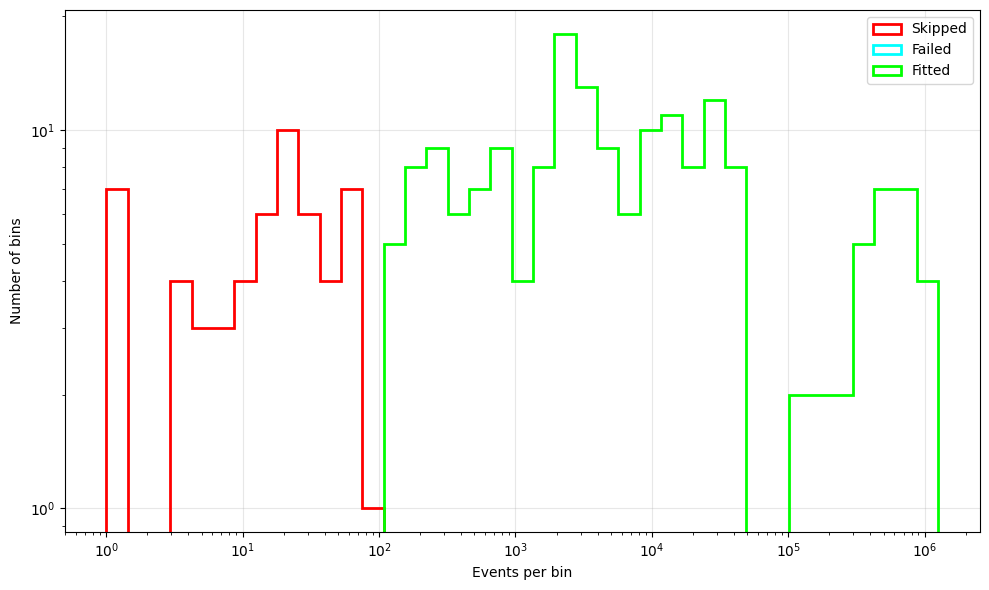

Skipped bins: 107 (37.2%)
Failed bins: 0 (0.0%)
Fitted bins: 181 (62.8%)


In [16]:
bin_success_dict = fplt.plot_event_count_distributions(
    fit_parameters,
    gamma_idx=gamma_idx,
    minimum_counts=minimum_counts,
    log_x=True,
    log_y=True,
)

Found 181 bins with stored fits
Showing best bins:
1: bin=(1, 2, 1), chi2=0.044
2: bin=(1, 5, 7), chi2=0.067
3: bin=(3, 6, 4), chi2=0.072
4: bin=(3, 6, 1), chi2=0.074
5: bin=(1, 0, 2), chi2=0.078
6: bin=(1, 0, 3), chi2=0.079


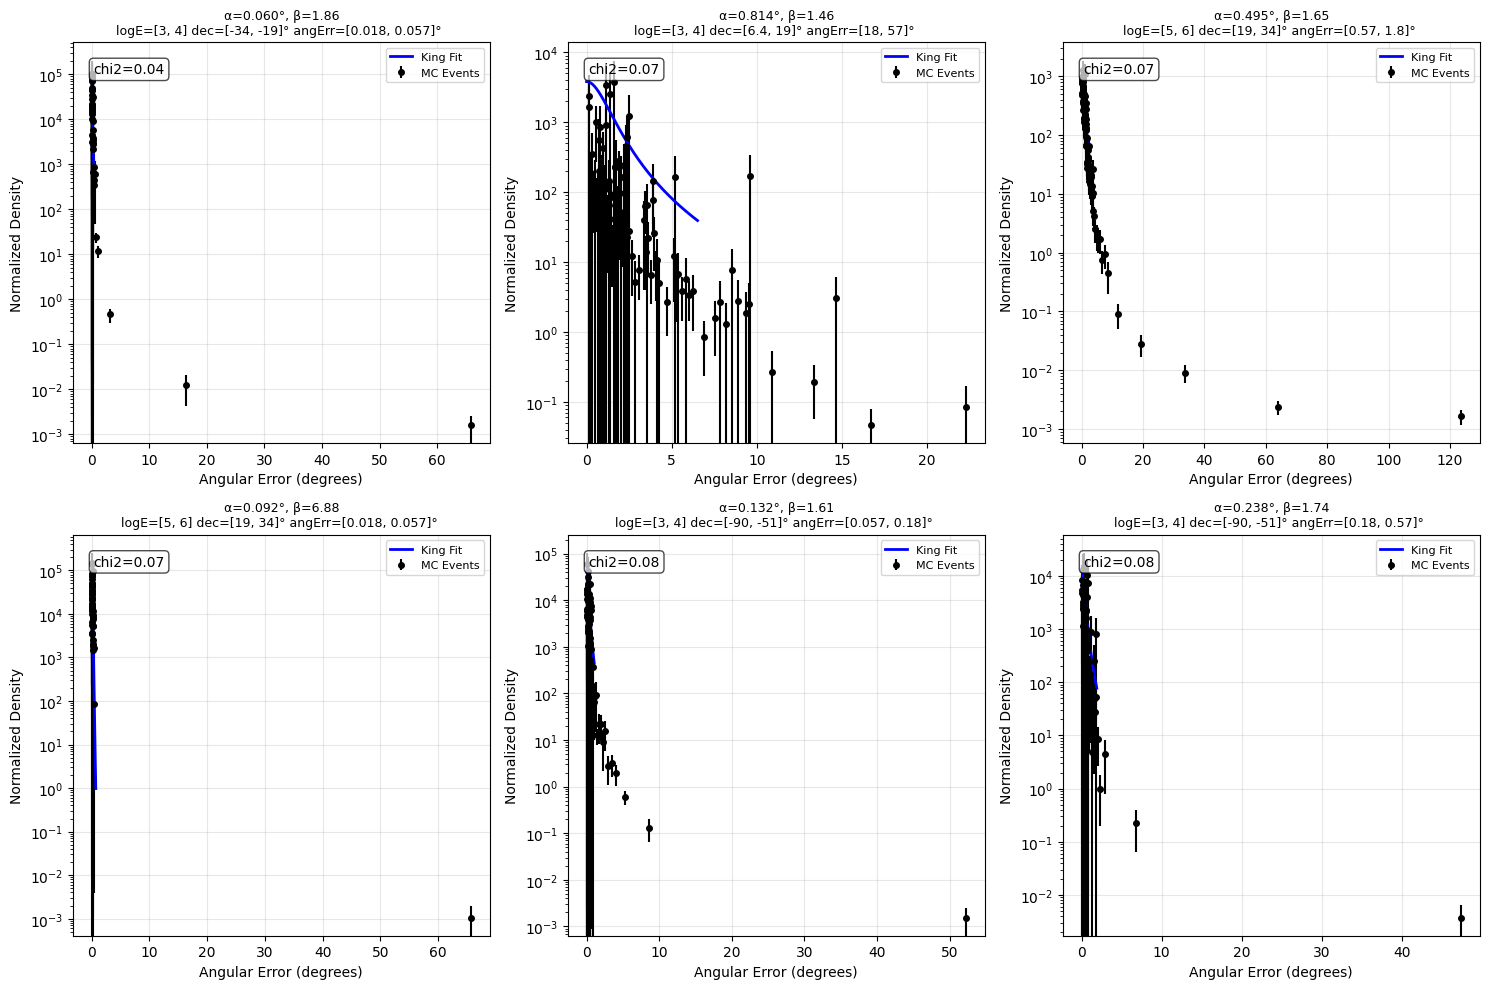

[((1, 2, 1), 0.04390306915342347),
 ((1, 5, 7), 0.06746202790514726),
 ((3, 6, 4), 0.07234212740896022),
 ((3, 6, 1), 0.07399248916394414),
 ((1, 0, 2), 0.07849411352914946),
 ((1, 0, 3), 0.07922747944486883)]

In [17]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="best",
    gamma_idx= gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
)

Found 181 bins with stored fits
Showing worst bins:
1: bin=(0, 8, 5), chi2=89.687
2: bin=(0, 8, 4), chi2=87.990
3: bin=(0, 8, 6), chi2=51.448
4: bin=(2, 1, 3), chi2=47.452
5: bin=(1, 8, 5), chi2=33.967
6: bin=(2, 0, 3), chi2=31.490


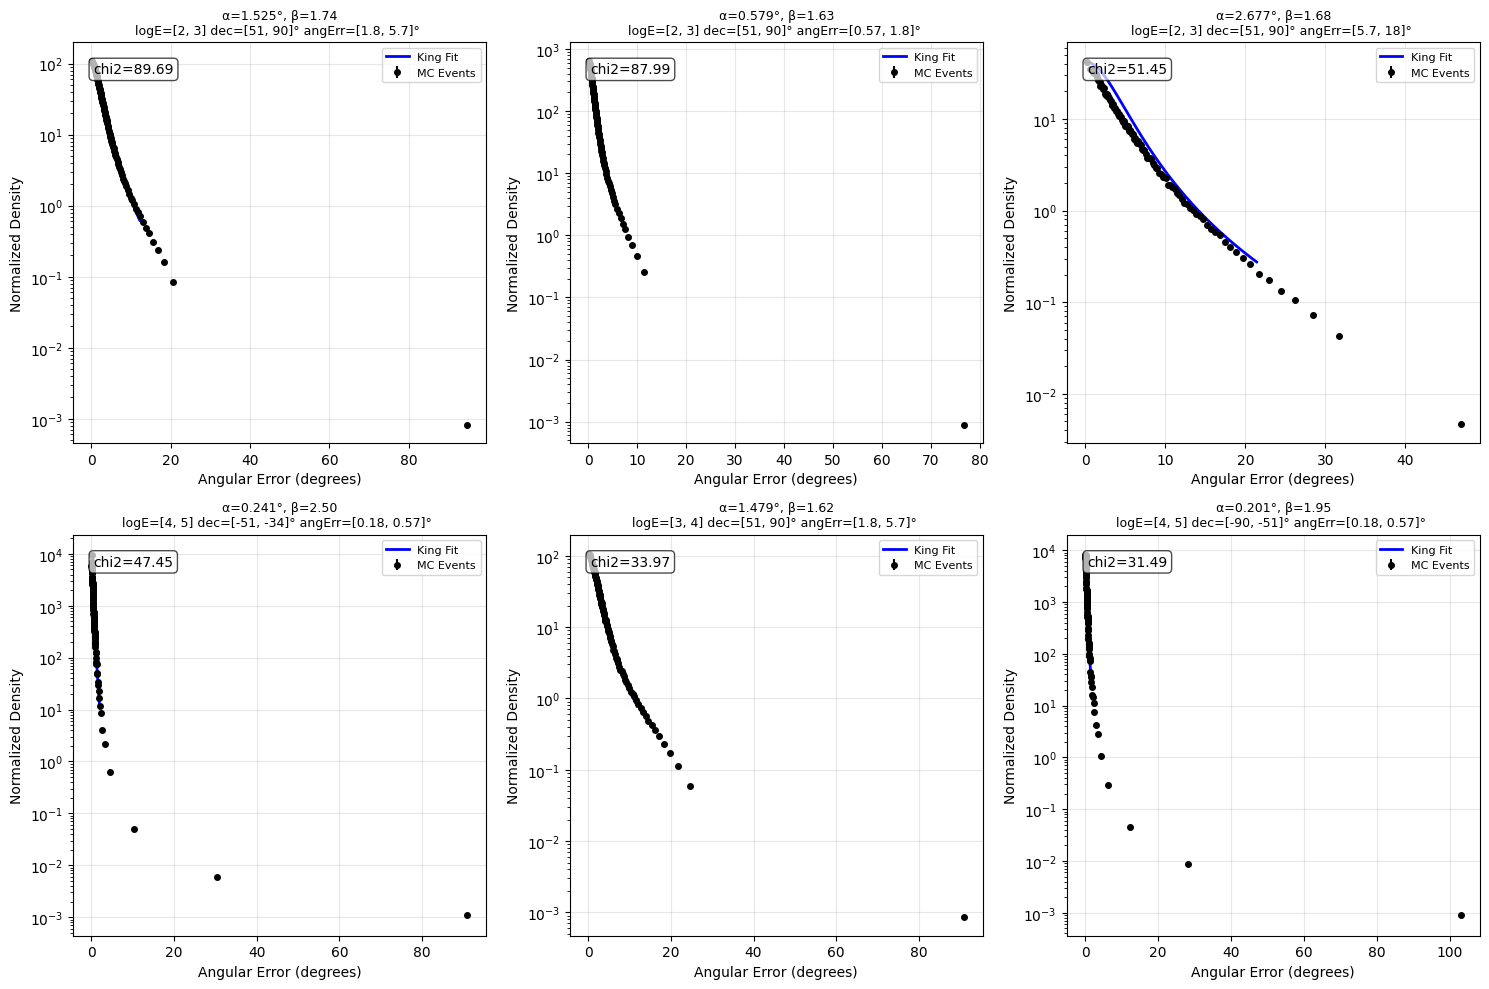

[((0, 8, 5), 89.68714892066636),
 ((0, 8, 4), 87.98962646188282),
 ((0, 8, 6), 51.44829488854658),
 ((2, 1, 3), 47.452432995198706),
 ((1, 8, 5), 33.96677476834855),
 ((2, 0, 3), 31.48965345442191)]

In [18]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="worst",
    gamma_idx=gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
)

Found 181 bins with stored fits
Showing random bins:
1: bin=(2, 5, 6), chi2=0.136
2: bin=(3, 0, 2), chi2=3.259
3: bin=(1, 8, 1), chi2=0.445
4: bin=(3, 3, 6), chi2=0.352
5: bin=(1, 8, 2), chi2=1.979
6: bin=(0, 6, 2), chi2=0.715


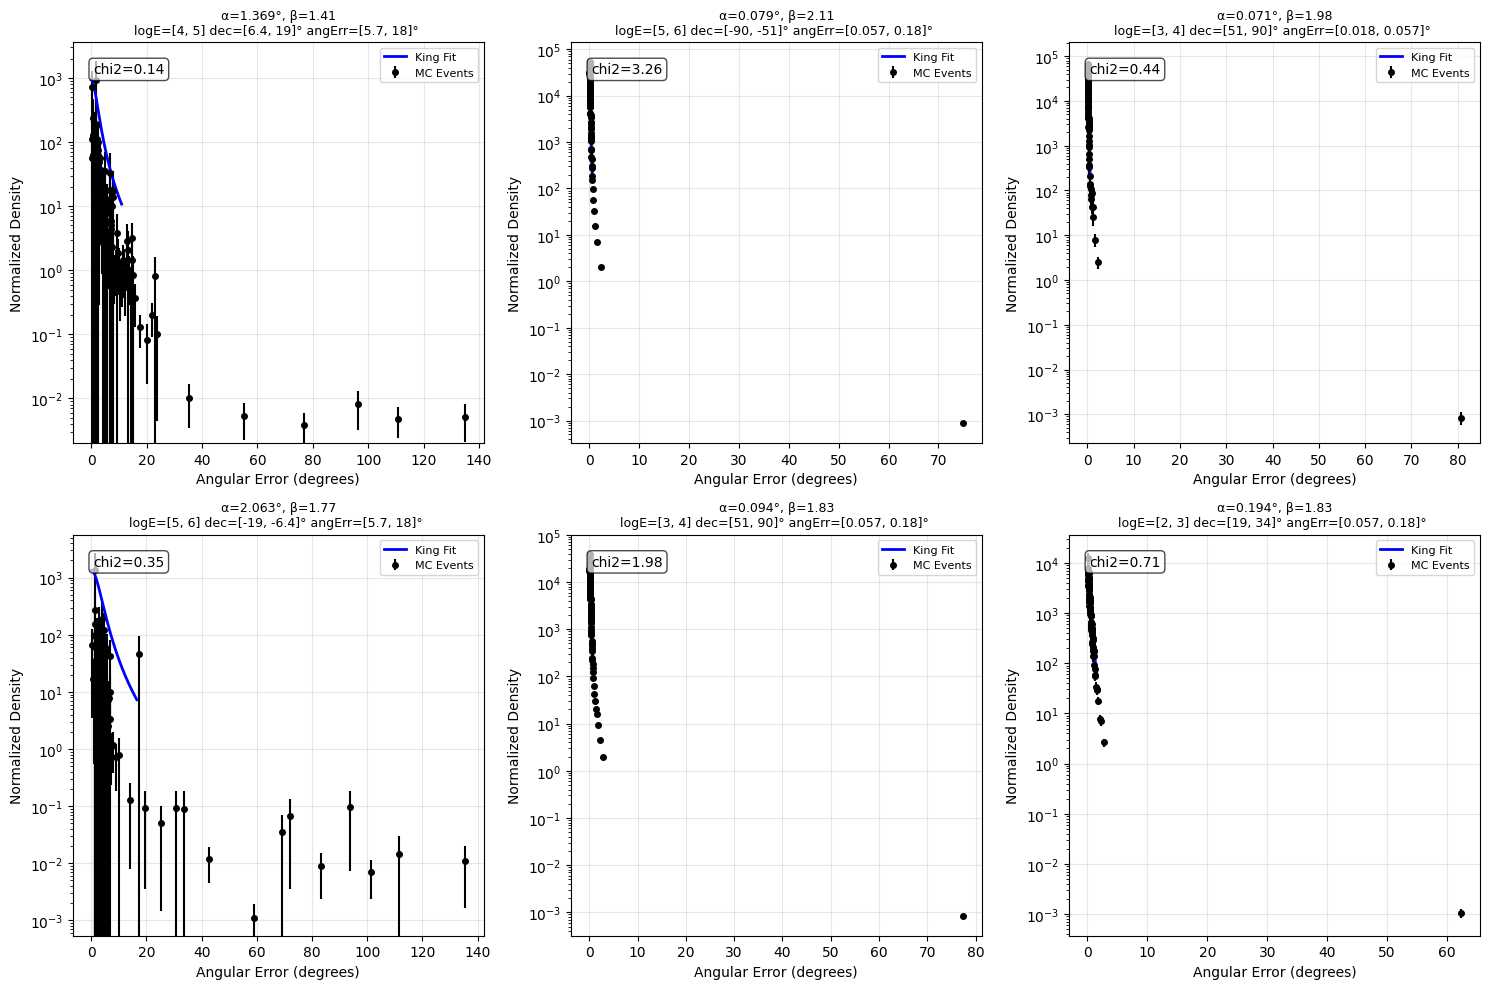

[((2, 5, 6), 0.13571898836113075),
 ((3, 0, 2), 3.259244442145886),
 ((1, 8, 1), 0.444992814503814),
 ((3, 3, 6), 0.35158087847183217),
 ((1, 8, 2), 1.978916996928874),
 ((0, 6, 2), 0.7148840392680874)]

In [19]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="random",
    gamma_idx=gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
    random_seed=42,
)

### Likelihood Analysis